## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as  plt

## Load Dataset

In [ ]:
df = pd.read_csv("smart_meter_data.csv")
df.head()

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,Normal
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,Normal
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,Normal
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,Normal
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,Normal


In [ ]:
print(df.shape)

(5000, 7)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Timestamp             5000 non-null   object 
 1   Electricity_Consumed  5000 non-null   float64
 2   Temperature           5000 non-null   float64
 3   Humidity              5000 non-null   float64
 4   Wind_Speed            5000 non-null   float64
 5   Avg_Past_Consumption  5000 non-null   float64
 6   Anomaly_Label         5000 non-null   object 
dtypes: float64(5), object(2)
memory usage: 273.6+ KB


In [ ]:
df.describe()

,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.376677,0.525069,0.497632,0.464628,0.458738
std,0.164117,0.135603,0.146781,0.120370,0.146749
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.265349,0.434253,0.398956,0.382906,0.358857
50%,0.377244,0.524052,0.497539,0.464958,0.457814
75%,0.486002,0.617281,0.595359,0.547419,0.555607
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

Timestamp               0
Electricity_Consumed    0
Temperature             0
Humidity                0
Wind_Speed              0
Avg_Past_Consumption    0
Anomaly_Label           0
dtype: int64

In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [ ]:
print(df.columns)

Index(['Timestamp', 'Electricity_Consumed', 'Temperature', 'Humidity',
       'Wind_Speed', 'Avg_Past_Consumption', 'Anomaly_Label'],
      dtype='object')


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.dropna(subset=['Timestamp'], inplace=True)

In [ ]:
# Convert Numeric Columns
numeric_cols = [
    'Electricity_Consumed',
    'Temperature',
    'Humidity',
    'Wind_Speed',
    'Avg_Past_Consumption'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df.dropna(subset=numeric_cols, inplace=True)

In [ ]:
# Convert Anomaly_Label (Text → Binary)
df['Anomaly_Label'] = df['Anomaly_Label'].map({
    'Normal': 0,
    'Abnormal': 1
})
df.dropna(subset=['Anomaly_Label'], inplace=True)

# DATA PREPROCESSING

In [ ]:
# Feature Engineering – Time Features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['Year'] = df['Timestamp'].dt.year

# Create Humidity Categories
bins = [0, 30, 60, 100]
labels = ['Low', 'Medium', 'High']
df['Humidity_Level'] = pd.cut(df['Humidity'], bins=bins, labels=labels)

# Create Consumption Category
avg_consumption = df['Electricity_Consumed'].mean()

df['Consumption_Level'] = df['Electricity_Consumed'].apply(
    lambda x: 'High' if x > avg_consumption else 'Low')

In [ ]:
df.head(5)

,Timestamp,Electricity_Consumed,Temperature,Humidity,Wind_Speed,Avg_Past_Consumption,Anomaly_Label,Hour,Day,Month,Year,Humidity_Level,Consumption_Level
0,2024-01-01 00:00:00,0.457786,0.469524,0.396368,0.445441,0.692057,0,0,1,1,2024,Low,High
1,2024-01-01 00:30:00,0.351956,0.465545,0.451184,0.458729,0.539874,0,0,1,1,2024,Low,Low
2,2024-01-01 01:00:00,0.482948,0.285415,0.408289,0.470360,0.614724,0,1,1,1,2024,Low,High
3,2024-01-01 01:30:00,0.628838,0.482095,0.512308,0.576241,0.757044,0,1,1,1,2024,Low,High
4,2024-01-01 02:00:00,0.335974,0.624741,0.672021,0.373004,0.673981,0,2,1,1,2024,Low,Low


# DATA VISUALIZATION

### Hourly Consumption

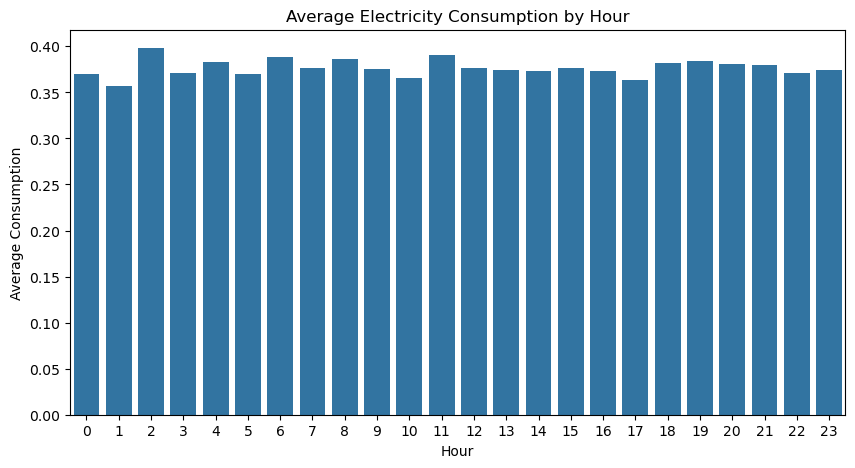

In [ ]:
hourly = df.groupby('Hour')['Electricity_Consumed'].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=hourly.index, y=hourly.values)

plt.title("Average Electricity Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Consumption")
plt.show()

### Monthly Consumption

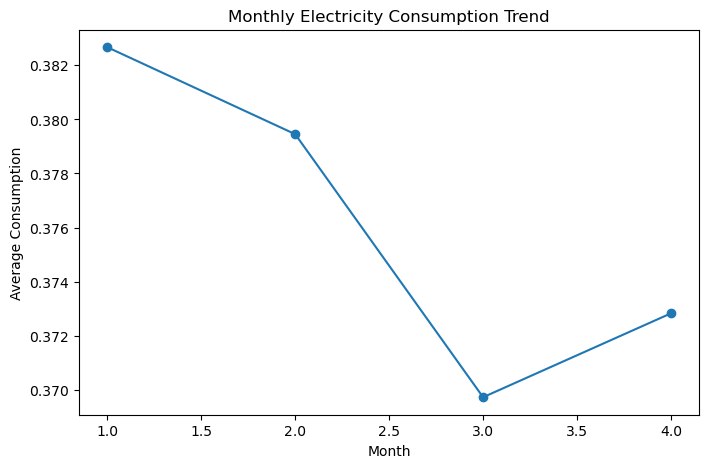

In [ ]:
monthly = df.groupby('Month')['Electricity_Consumed'].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title("Monthly Electricity Consumption Trend")
plt.xlabel("Month")
plt.ylabel("Average Consumption")
plt.show()

### Temperature vs Consumption

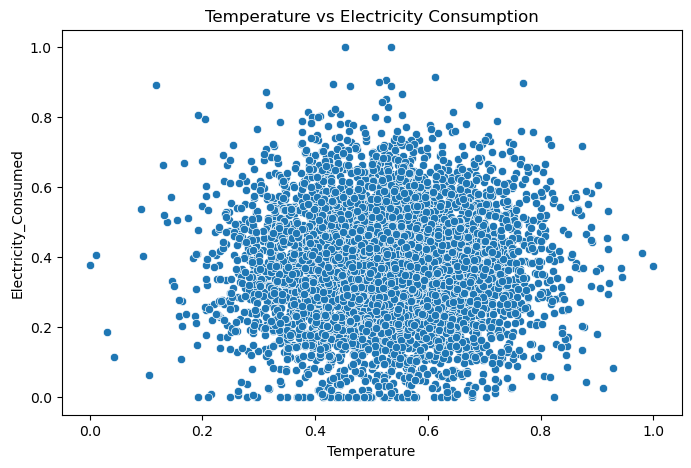

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Electricity_Consumed', data=df)

plt.title("Temperature vs Electricity Consumption")
plt.show()


### Electricity Consumption Distribution

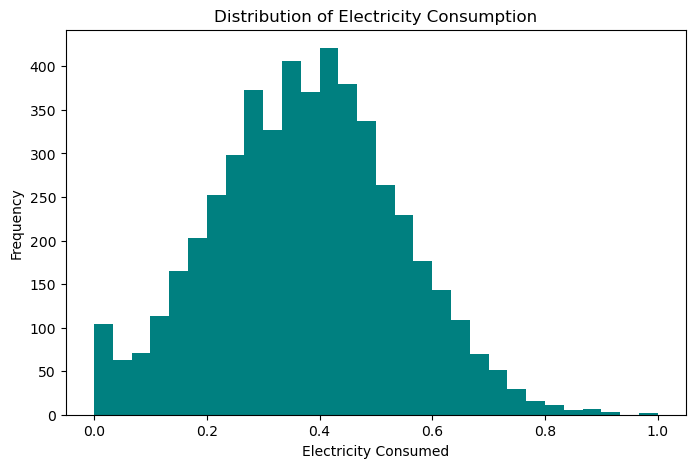

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Electricity_Consumed'], bins=30,color="teal")

plt.title("Distribution of Electricity Consumption")
plt.xlabel("Electricity Consumed")
plt.ylabel("Frequency")
plt.show()

### Anomaly Distribution

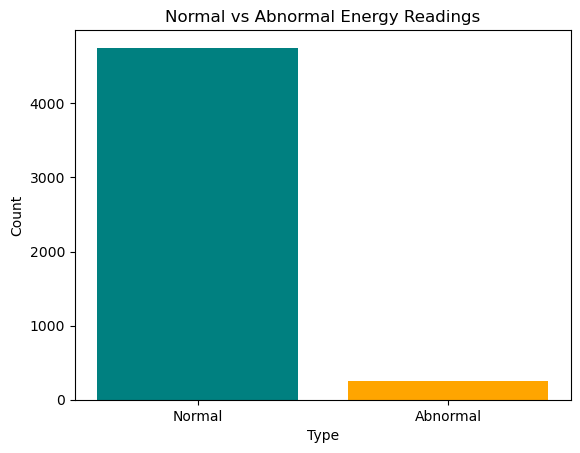

In [ ]:
normal = len(df[df['Anomaly_Label'] == 0])
abnormal = len(df[df['Anomaly_Label'] == 1])

plt.bar(['Normal', 'Abnormal'], [normal, abnormal],
        color=['teal', 'orange'])

plt.title("Normal vs Abnormal Energy Readings")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


### Correlation Heatmap

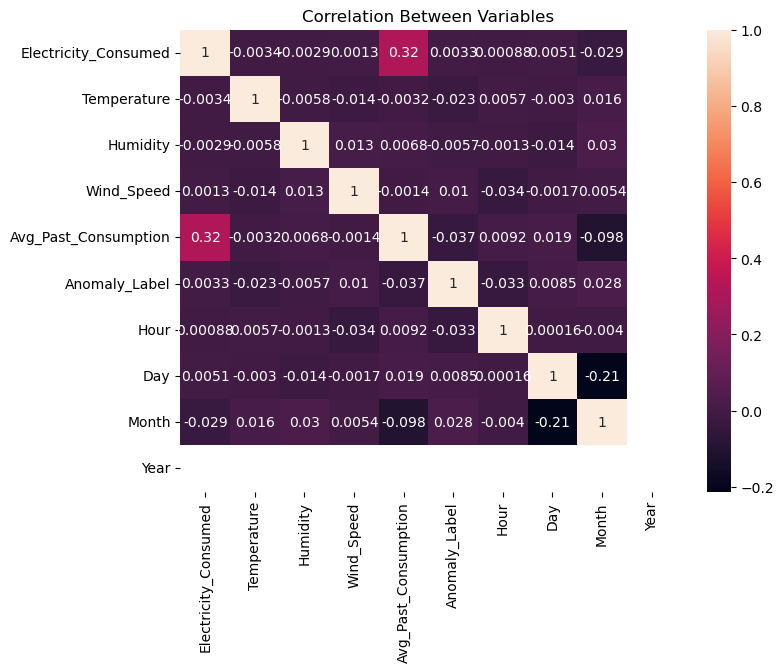

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Between Variables")
plt.show()


### Heatmap for Hour vs Month

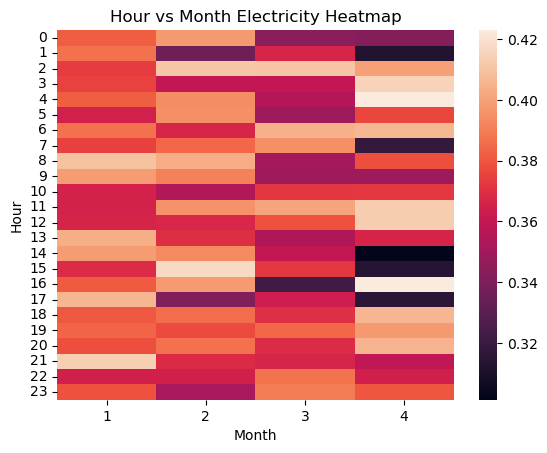

In [ ]:
pivot_table = df.pivot_table(values='Electricity_Consumed',index='Hour',columns='Month',aggfunc='mean')
sns.heatmap(pivot_table)

plt.title("Hour vs Month Electricity Heatmap")
plt.show()
